# Gesture-Controlled Robot
## Complete Implementation

This notebook covers:
1. Dataset loading & preprocessing
2. CNN model training
3. Model evaluation (accuracy, confusion matrix, classification report)
4. Gesture-to-robot command mapping
5. 2D robot simulation

## 1. Imports & Setup

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
from IPython.display import display, clear_output
import pandas as pd
import time

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense,
                                     Flatten, Dropout, BatchNormalization)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau)
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)
print("GPUs available:", len(tf.config.list_physical_devices('GPU')))


2026-05-03 16:03:45.937451: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777824226.134886      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777824226.187706      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777824226.637327      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777824226.637377      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777824226.637380      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: 1


## 2. Dataset Loading & Preprocessing

In [2]:
DATASET_PATH = "/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog"
IMG_SIZE = 64

print(os.listdir(DATASET_PATH))


['07', '05', '06', '02', '04', '00', '08', '09', '03', '01']


In [3]:
images = []
labels = []
subjects = []
total_images = 0

for subject in sorted(os.listdir(DATASET_PATH)):
    subject_path = os.path.join(DATASET_PATH, subject)
    if not os.path.isdir(subject_path):
        continue
    print(f"\nProcessing Subject: {subject}")

    for gesture in sorted(os.listdir(subject_path)):
        gesture_path = os.path.join(subject_path, gesture)
        if not os.path.isdir(gesture_path):
            continue

        image_count = 0
        for img_file in os.listdir(gesture_path):
            img_path = os.path.join(gesture_path, img_file)
            try:
                image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
                images.append(image)
                labels.append(gesture)
                subjects.append(subject)
                image_count += 1
                total_images += 1
                if total_images % 500 == 0:
                    print(f"   {total_images} images processed...")
            except Exception as e:
                print("Error loading:", img_path, e)

        print(f"  Loaded {image_count} images for gesture '{gesture}'")

print("\nFinished loading dataset")
print("Total images loaded:", total_images)



Processing Subject: 00
  Loaded 200 images for gesture '01_palm'
  Loaded 200 images for gesture '02_l'
   500 images processed...
  Loaded 200 images for gesture '03_fist'
  Loaded 200 images for gesture '04_fist_moved'
   1000 images processed...
  Loaded 200 images for gesture '05_thumb'
  Loaded 200 images for gesture '06_index'
  Loaded 200 images for gesture '07_ok'
   1500 images processed...
  Loaded 200 images for gesture '08_palm_moved'
  Loaded 200 images for gesture '09_c'
   2000 images processed...
  Loaded 200 images for gesture '10_down'

Processing Subject: 01
  Loaded 200 images for gesture '01_palm'
  Loaded 200 images for gesture '02_l'
   2500 images processed...
  Loaded 200 images for gesture '03_fist'
  Loaded 200 images for gesture '04_fist_moved'
   3000 images processed...
  Loaded 200 images for gesture '05_thumb'
  Loaded 200 images for gesture '06_index'
  Loaded 200 images for gesture '07_ok'
   3500 images processed...
  Loaded 200 images for gesture '0

In [4]:
X = np.array(images)
y = np.array(labels)
subject_ids = np.array(subjects)

print("Image dataset shape:", X.shape)
print("Labels shape:", y.shape)


Image dataset shape: (20000, 64, 64)
Labels shape: (20000,)


In [5]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
NUM_CLASSES = len(encoder.classes_)

print("Gesture Classes:", encoder.classes_)
print("Number of classes:", NUM_CLASSES)


Gesture Classes: ['01_palm' '02_l' '03_fist' '04_fist_moved' '05_thumb' '06_index' '07_ok'
 '08_palm_moved' '09_c' '10_down']
Number of classes: 10


In [6]:
# Normalize and reshape
X = X / 255.0
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
print("Normalized shape:", X.shape)
print("Pixel range:", X.min(), "to", X.max())


Normalized shape: (20000, 64, 64, 1)
Pixel range: 0.00392156862745098 to 0.9921568627450981


01_palm          2000
02_l             2000
03_fist          2000
04_fist_moved    2000
05_thumb         2000
06_index         2000
07_ok            2000
08_palm_moved    2000
09_c             2000
10_down          2000
Name: count, dtype: int64


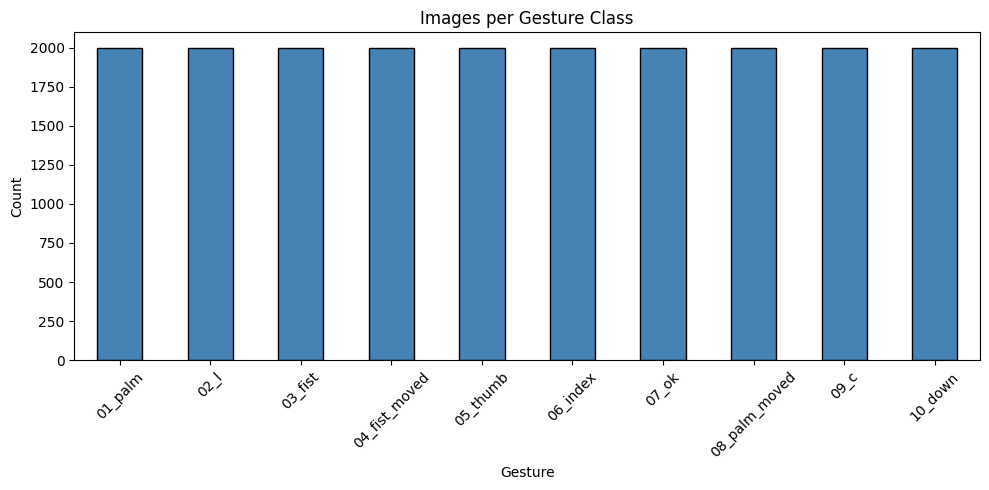

In [7]:
# Class distribution bar chart
gesture_counts = pd.Series(labels).value_counts().sort_index()
print(gesture_counts)

gesture_counts.plot(kind='bar', figsize=(10, 5),
                    title='Images per Gesture Class',
                    color='steelblue', edgecolor='black')
plt.xlabel('Gesture')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


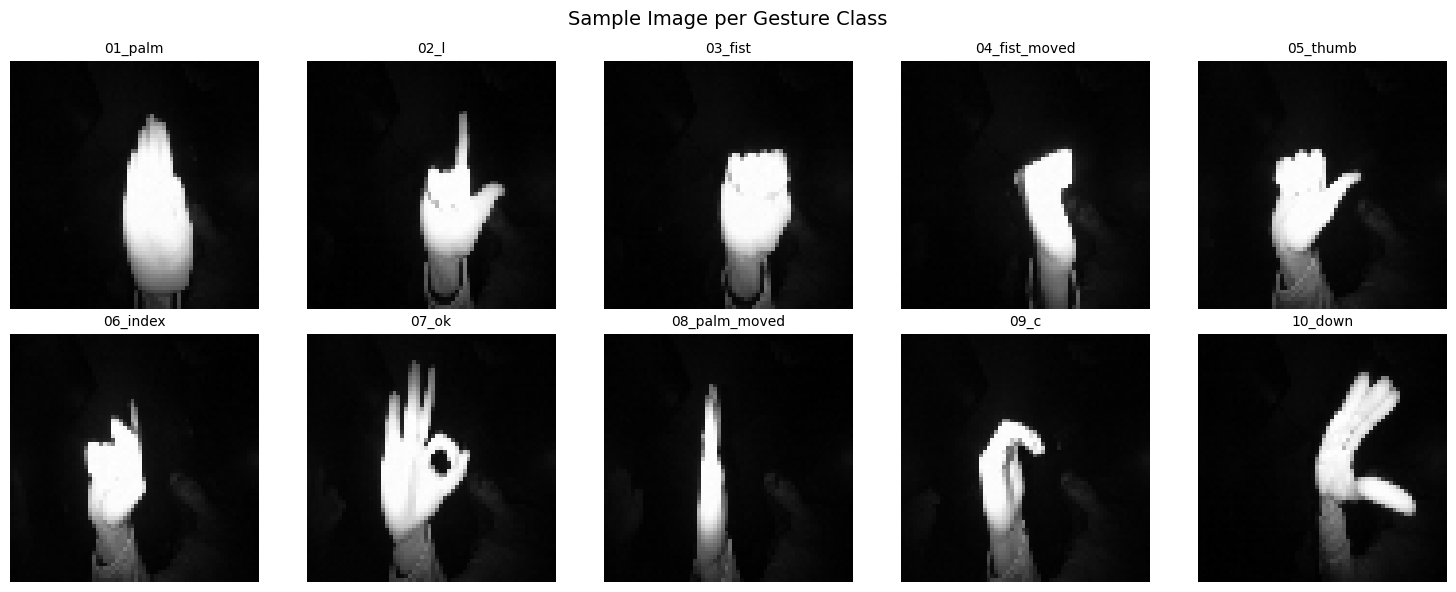

In [8]:
# Show one sample per gesture class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
labels_list = list(labels)

for i, gesture in enumerate(encoder.classes_):
    idx = labels_list.index(gesture)
    axes[i].imshow(X[idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    axes[i].set_title(gesture, fontsize=10)
    axes[i].axis('off')

plt.suptitle('Sample Image per Gesture Class', fontsize=14)
plt.tight_layout()
plt.show()


## 3. Train / Validation / Test Split

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.30,
    stratify=y_encoded,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(f"Train:      X={X_train.shape}  y={y_train.shape}")
print(f"Validation: X={X_val.shape}    y={y_val.shape}")
print(f"Test:       X={X_test.shape}   y={y_test.shape}")


Train:      X=(14000, 64, 64, 1)  y=(14000,)
Validation: X=(3000, 64, 64, 1)    y=(3000,)
Test:       X=(3000, 64, 64, 1)   y=(3000,)


In [10]:
# One-hot encode labels
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print("y_train_cat:", y_train_cat.shape)
print("y_val_cat:  ", y_val_cat.shape)
print("y_test_cat: ", y_test_cat.shape)


y_train_cat: (14000, 10)
y_val_cat:   (3000, 10)
y_test_cat:  (3000, 10)


## 4. Data Augmentation

In [11]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)


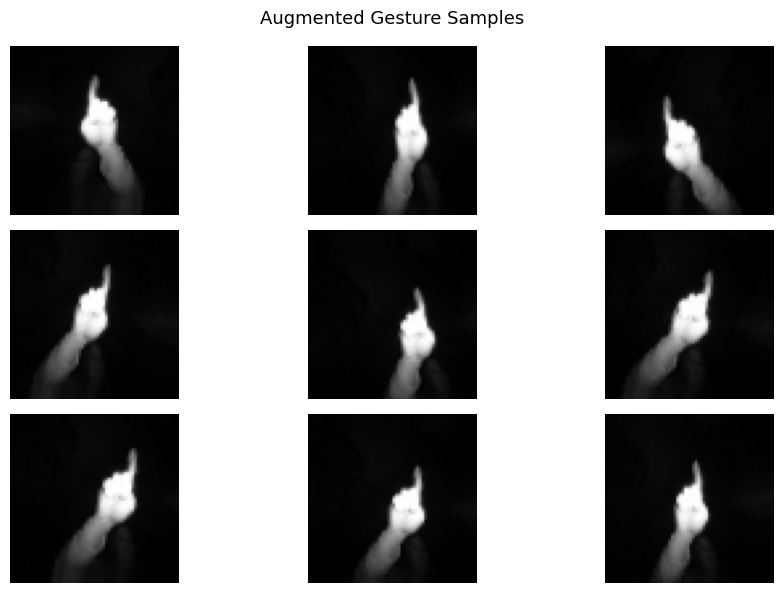

In [12]:
# Visualise augmented samples from a single image
sample_image = X_train[0].reshape(1, IMG_SIZE, IMG_SIZE, 1)
aug_iter = datagen.flow(sample_image, batch_size=1)

fig, axes = plt.subplots(3, 3, figsize=(10, 6))
for ax in axes.flatten():
    batch = next(aug_iter)
    ax.imshow(batch[0].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    ax.axis('off')

plt.suptitle('Augmented Gesture Samples', fontsize=13)
plt.tight_layout()
plt.show()


## 5. CNN Model Architecture

In [13]:
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Classifier head
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777824531.934684      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,276,042 (4.87 MB)

 Trainable params: 1,275,594 (4.87 MB)

 Non-trainable params: 448 (1.75 KB)

## 6. Model Training

In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/kaggle/working/best_gesture_model.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3,
                      min_lr=1e-5, verbose=1)
]

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=50,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1777824535.921622     134 service.cc:152] XLA service 0x7dc880010f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777824535.921670     134 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777824536.444119     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


 10/438 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.1270 - loss: 5.3311

I0000 00:00:1777824540.016575     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3672 - loss: 2.1250
Epoch 1: val_accuracy improved from -inf to 0.12433, saving model to /kaggle/working/best_gesture_model.h5


...

438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9188 - loss: 0.2442 - val_accuracy: 0.9693 - val_loss: 0.0938 - learning_rate: 0.0010
Epoch 4/50
437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9576 - loss: 0.1369
Epoch 4: val_accuracy did not improve from 0.96933
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9576 - loss: 0.1370 - val_accuracy: 0.9323 - val_loss: 0.1822 - learning_rate: 0.0010
Epoch 5/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9646 - loss: 0.1212
Epoch 5: val_accuracy improved from 0.96933 to 0.99467, saving model to /kaggle/working/best_gesture_model.h5


438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9646 - loss: 0.1212 - val_accuracy: 0.9947 - val_loss: 0.0249 - learning_rate: 0.0010
Epoch 6/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9671 - loss: 0.1151
Epoch 6: val_accuracy did not improve from 0.99467
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9671 - loss: 0.1150 - val_accuracy: 0.9000 - val_loss: 0.3850 - learning_rate: 0.0010
Epoch 7/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9769 - loss: 0.0854
Epoch 7: val_accuracy did not improve from 0.99467
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9769 - loss: 0.0854 - val_accuracy: 0.7173 - val_loss: 0.9489 - learning_rate: 0.0010
Epoch 8/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9698 - loss: 0.1126
Epoch 8: val_accuracy did not improve from 0.99467

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9698 - loss: 0.1126 - val_

438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9927 - loss: 0.0212 - val_accuracy: 0.9970 - val_loss: 0.0059 - learning_rate: 2.0000e-04
Epoch 13/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9943 - loss: 0.0198
Epoch 13: val_accuracy improved from 0.99700 to 0.99900, saving model to /kaggle/working/best_gesture_model.h5


438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9943 - loss: 0.0198 - val_accuracy: 0.9990 - val_loss: 0.0043 - learning_rate: 2.0000e-04
Epoch 14/50
437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9945 - loss: 0.0186
Epoch 14: val_accuracy did not improve from 0.99900
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9945 - loss: 0.0186 - val_accuracy: 0.9957 - val_loss: 0.0122 - learning_rate: 2.0000e-04
Epoch 15/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9957 - loss: 0.0182
Epoch 15: val_accuracy did not improve from 0.99900
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9957 - loss: 0.0182 - val_accuracy: 0.9903 - val_loss: 0.0335 - learning_rate: 2.0000e-04
Epoch 16/50
437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9960 - loss: 0.0129
Epoch 16: val_accuracy improved from 0.99900 to 0.99933, saving model to /kaggle/working/best_gesture_model.h5


438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9960 - loss: 0.0129 - val_accuracy: 0.9993 - val_loss: 0.0032 - learning_rate: 2.0000e-04
Epoch 17/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9962 - loss: 0.0127
Epoch 17: val_accuracy did not improve from 0.99933
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9962 - loss: 0.0127 - val_accuracy: 0.9827 - val_loss: 0.0687 - learning_rate: 2.0000e-04
Epoch 18/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9960 - loss: 0.0161
Epoch 18: val_accuracy did not improve from 0.99933
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9960 - loss: 0.0161 - val_accuracy: 0.9960 - val_loss: 0.0086 - learning_rate: 2.0000e-04
Epoch 19/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9961 - loss: 0.0126
Epoch 19: val_accuracy did not improve from 0.99933

Epoch 19: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9961 - 

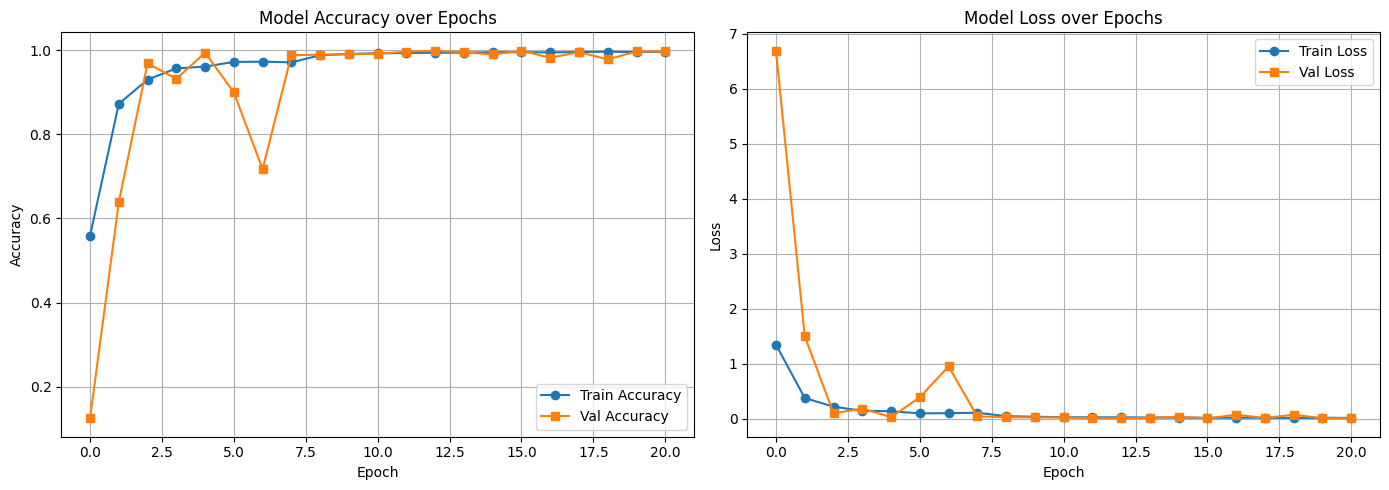

In [15]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],    'o-', label='Train Accuracy')
ax1.plot(history.history['val_accuracy'],'s-', label='Val Accuracy')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'],     'o-', label='Train Loss')
ax2.plot(history.history['val_loss'], 's-', label='Val Loss')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


## 7. Model Evaluation on Test Set

In [16]:
# Load best saved weights
model = load_model('/kaggle/working/best_gesture_model.h5')

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy : {test_acc * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")


Test Accuracy : 99.90%
Test Loss     : 0.0030


In [17]:
# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat,   axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=encoder.classes_))


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Classification Report:
               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       300
         02_l       1.00      1.00      1.00       300
      03_fist       0.99      1.00      1.00       300
04_fist_moved       1.00      0.99      1.00       300
     05_thumb       1.00      1.00      1.00       300
     06_index       1.00      1.00      1.00       300
        07_ok       1.00      1.00      1.00       300
08_palm_moved       1.00      1.00      1.00       300
         09_c       1.00      1.00      1.00       300
      10_down       1.00      1.00      1.00       300

     accuracy                           1.00      3000
    macro avg       1.00      1.00      1.00      3000
 weighted avg       1.00      1.00      1.00      3000



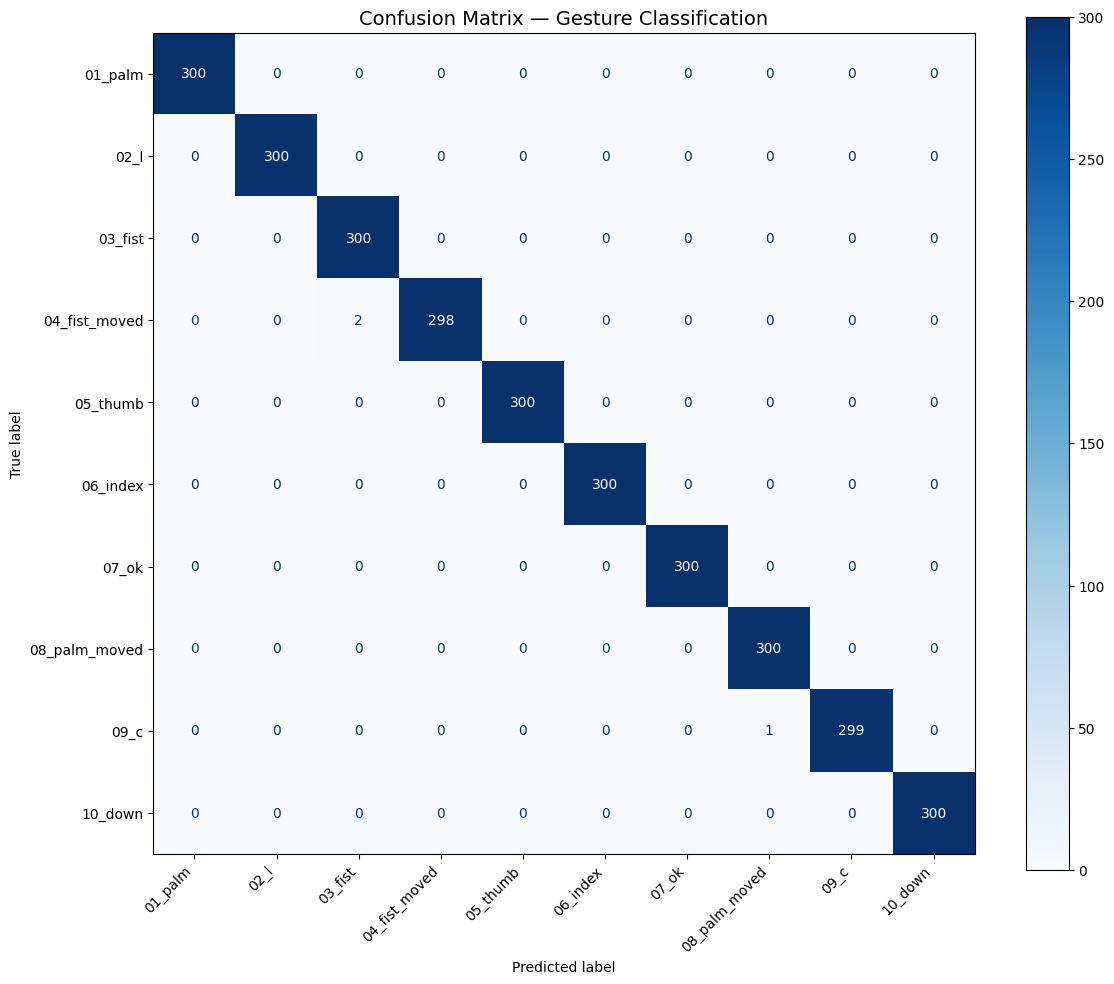

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=encoder.classes_)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Gesture Classification', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


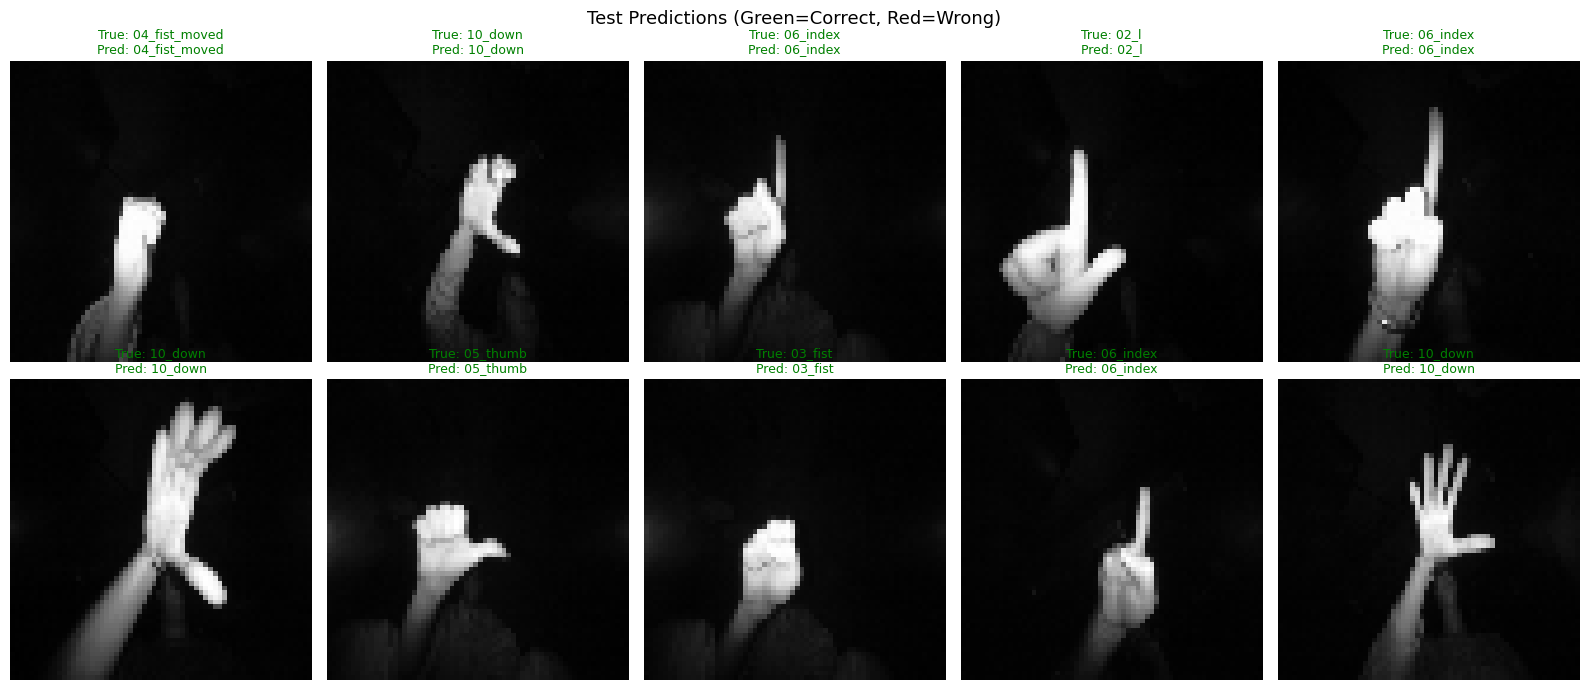

In [19]:
# Visualise some predictions vs ground truth
n_samples = 10
sample_indices = np.random.choice(len(X_test), n_samples, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    axes[i].imshow(X_test[idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    true_label = encoder.classes_[y_true[idx]]
    pred_label = encoder.classes_[y_pred[idx]]
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Test Predictions (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.show()


## 8. Gesture-to-Robot Command Mapping

In [20]:
# -----------------------------------------------------------
# Adjust keys to match your dataset's exact gesture folder
# names (encoder.classes_). Common LeapGestRecog names:
#   01_palm, 02_l, 03_fist, 04_fist_moved, 05_thumb,
#   06_index, 07_ok, 08_palm_moved, 09_c, 10_down
# -----------------------------------------------------------

GESTURE_COMMAND_MAP = {
    "01_palm":       "STOP",
    "02_l":          "TURN_LEFT",
    "03_fist":       "MOVE_FORWARD",
    "04_fist_moved": "MOVE_BACKWARD",
    "05_thumb":      "SPEED_UP",
    "06_index":      "POINT / SELECT",
    "07_ok":         "CONFIRM",
    "08_palm_moved": "MOVE_RIGHT",
    "09_c":          "GRAB",
    "10_down":       "TURN_RIGHT",
}

print("Gesture → Command Mapping")
print("-" * 40)
for gesture, command in GESTURE_COMMAND_MAP.items():
    print(f"  {gesture:<20} →  {command}")


Gesture → Command Mapping
----------------------------------------
  01_palm              →  STOP
  02_l                 →  TURN_LEFT
  03_fist              →  MOVE_FORWARD
  04_fist_moved        →  MOVE_BACKWARD
  05_thumb             →  SPEED_UP
  06_index             →  POINT / SELECT
  07_ok                →  CONFIRM
  08_palm_moved        →  MOVE_RIGHT
  09_c                 →  GRAB
  10_down              →  TURN_RIGHT


In [21]:
def predict_gesture(image_array):
    """
    Predict gesture label and corresponding robot command
    from a single pre-processed image array (64x64 grayscale).
    """
    img = image_array.reshape(1, IMG_SIZE, IMG_SIZE, 1).astype('float32')
    img = img / 255.0 if img.max() > 1.0 else img   # ensure normalised
    probs = model.predict(img, verbose=0)
    class_idx = np.argmax(probs)
    gesture   = encoder.classes_[class_idx]
    confidence = probs[0][class_idx]
    command   = GESTURE_COMMAND_MAP.get(gesture, "UNKNOWN")
    return gesture, command, confidence

# Quick smoke-test on 5 random test samples
print(f"{'True Gesture':<22} {'Predicted':<22} {'Command':<18} {'Conf':>6}")
print("-" * 72)
for _ in range(5):
    idx = np.random.randint(len(X_test))
    raw_img = (X_test[idx] * 255).astype(np.uint8)
    g, cmd, conf = predict_gesture(raw_img)
    true_g = encoder.classes_[y_true[idx]]
    print(f"{true_g:<22} {g:<22} {cmd:<18} {conf:.2%}")


True Gesture           Predicted              Command              Conf
------------------------------------------------------------------------
06_index               06_index               POINT / SELECT     100.00%
04_fist_moved          04_fist_moved          MOVE_BACKWARD      100.00%
06_index               06_index               POINT / SELECT     100.00%
03_fist                03_fist                MOVE_FORWARD       100.00%
01_palm                01_palm                STOP               100.00%


## 9. 2D Robot Simulation

The simulation renders a top-down robot on a grid. Predicted gestures move / rotate the robot in real time.

In [22]:
# ─── Robot State ────────────────────────────────────────────────────────────
class Robot:
    """Simple 2-D robot with position and heading (degrees)."""

    def __init__(self, x=5.0, y=5.0, heading=90, step=0.5):
        self.x       = x
        self.y       = y
        self.heading = heading   # degrees; 90 = facing up
        self.step    = step
        self.trail   = [(x, y)]
        self.last_cmd = "IDLE"

    def execute(self, command):
        self.last_cmd = command
        rad = np.radians(self.heading)

        if command == "MOVE_FORWARD":
            self.x += self.step * np.cos(rad)
            self.y += self.step * np.sin(rad)
        elif command == "MOVE_BACKWARD":
            self.x -= self.step * np.cos(rad)
            self.y -= self.step * np.sin(rad)
        elif command == "TURN_LEFT":
            self.heading = (self.heading + 15) % 360
        elif command == "TURN_RIGHT":
            self.heading = (self.heading - 15) % 360
        elif command == "MOVE_RIGHT":
            perp = np.radians(self.heading - 90)
            self.x += self.step * np.cos(perp)
            self.y += self.step * np.sin(perp)
        elif command == "SPEED_UP":
            self.step = min(self.step + 0.2, 1.5)
        elif command == "STOP":
            pass   # intentionally idle
        elif command == "GRAB":
            pass

        # Clamp to grid [0, 10]
        self.x = np.clip(self.x, 0, 10)
        self.y = np.clip(self.y, 0, 10)
        self.trail.append((self.x, self.y))

    def draw(self, ax):
        ax.clear()
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.set_aspect('equal')
        ax.set_facecolor('#1a1a2e')
        ax.grid(True, color='#2a2a4e', linewidth=0.5)
        ax.set_title('Robot Simulation — Top-Down View', color='white', fontsize=13, pad=10)
        ax.tick_params(colors='white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#444')

        # Trail
        if len(self.trail) > 1:
            tx, ty = zip(*self.trail)
            ax.plot(tx, ty, '-', color='#00bfff', alpha=0.5, linewidth=1.5)

        # Robot body (circle)
        circle = plt.Circle((self.x, self.y), 0.35, color='#ff6b6b', zorder=5)
        ax.add_patch(circle)

        # Direction arrow
        rad = np.radians(self.heading)
        ax.annotate('', xy=(self.x + 0.6 * np.cos(rad),
                             self.y + 0.6 * np.sin(rad)),
                    xytext=(self.x, self.y),
                    arrowprops=dict(arrowstyle='->', color='#ffd700',
                                   lw=2.5),
                    zorder=6)

        # HUD
        hud = (f"Position : ({self.x:.1f}, {self.y:.1f})\n"
               f"Heading  : {self.heading}°\n"
               f"Command  : {self.last_cmd}\n"
               f"Speed    : {self.step:.1f}")
        ax.text(0.02, 0.97, hud, transform=ax.transAxes,
                fontsize=9, verticalalignment='top',
                color='white',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#0d0d1a',
                          alpha=0.8, edgecolor='#444'))

print("Robot class defined ✓")


Robot class defined ✓


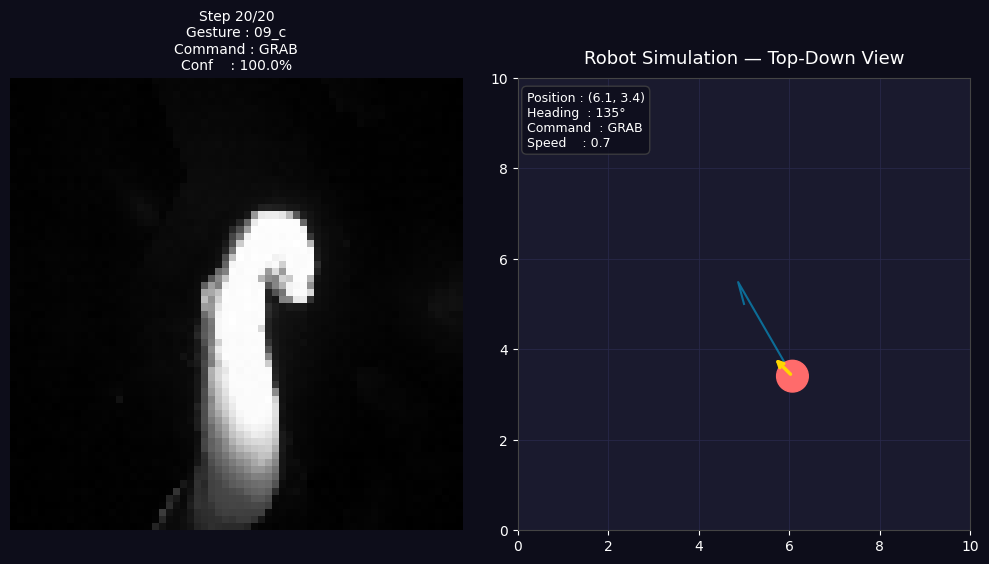


Simulation complete.


In [23]:
# ─── Run simulation on a random batch from the test set ─────────────────────

robot = Robot(x=5, y=5, heading=90)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d0d1a')

N_STEPS = 20
sample_idx = np.random.choice(len(X_test), N_STEPS, replace=False)

for step, idx in enumerate(sample_idx):
    # Predict from test image
    raw_img = (X_test[idx] * 255).astype(np.uint8)
    gesture, command, confidence = predict_gesture(raw_img)

    # Execute on robot
    robot.execute(command)

    # Left panel: gesture image
    axes[0].clear()
    axes[0].imshow(X_test[idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    axes[0].set_title(
        f"Step {step+1}/{N_STEPS}\nGesture : {gesture}\nCommand : {command}\nConf    : {confidence:.1%}",
        color='white', fontsize=10
    )
    axes[0].axis('off')
    axes[0].set_facecolor('#0d0d1a')

    # Right panel: robot map
    robot.draw(axes[1])

    plt.tight_layout(pad=2)
    clear_output(wait=True)
    display(fig)
    time.sleep(0.2)

plt.close()
print("\nSimulation complete.")


## 10. Batch Prediction Table

Summarise predicted commands across the full test set.

In [ ]:
results = []
for idx in range(len(X_test)):
    raw_img = (X_test[idx] * 255).astype(np.uint8)
    g, cmd, conf = predict_gesture(raw_img)
    true_g = encoder.classes_[y_true[idx]]
    results.append({
        'True Gesture': true_g,
        'Predicted Gesture': g,
        'Command': cmd,
        'Confidence': f"{conf:.2%}",
        'Correct': true_g == g
    })

df_results = pd.DataFrame(results)
print(f"Overall Accuracy: {df_results['Correct'].mean():.2%}")
print(f"\nCommand Distribution:")
print(df_results['Command'].value_counts())
df_results.head(20)


In [ ]:
# Command distribution pie chart
cmd_counts = df_results['Command'].value_counts()

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    cmd_counts.values,
    labels=cmd_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    colors=plt.cm.tab10.colors
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title('Distribution of Robot Commands\n(predicted on test set)', fontsize=13)
plt.tight_layout()
plt.show()


## 11. Save & Export

In [ ]:
# Save final model
model.save('/kaggle/working/gesture_robot_model_final.h5')
print("Model saved → gesture_robot_model_final.h5")

# Save label encoder classes
np.save('/kaggle/working/gesture_classes.npy', encoder.classes_)
print("Classes saved → gesture_classes.npy")


In [ ]:
np.save('/kaggle/working/gesture_classes.npy', encoder.classes_)
print("Classes saved:", encoder.classes_)

In [ ]:
# ─── Inference helper for deployment / new images ───────────────────────────

def predict_from_path(image_path, model, encoder, gesture_map,
                      img_size=64):
    """
    Load an image from disk and return (gesture, command, confidence).
    Works with grayscale or colour images.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot load image: {image_path}")
    img = cv2.resize(img, (img_size, img_size))
    img_norm = img.astype('float32') / 255.0
    img_input = img_norm.reshape(1, img_size, img_size, 1)

    probs = model.predict(img_input, verbose=0)
    class_idx = np.argmax(probs)
    gesture   = encoder.classes_[class_idx]
    confidence = probs[0][class_idx]
    command   = gesture_map.get(gesture, "UNKNOWN")
    return gesture, command, confidence


print("predict_from_path() helper ready.")
print("Usage:")
print("  gesture, command, conf = predict_from_path('hand.png', model, encoder, GESTURE_COMMAND_MAP)")
